In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from dataset import ClockDataset  # ה-Dataset המעודכן שלך

In [2]:

# ===================== 1. Define Model (U-net) =====================
class ClockEraserUNet(nn.Module):
    def __init__(self):
        super(ClockEraserUNet, self).__init__()
        
        # Encoder
        self.enc1 = self.conv_block(3, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = self.conv_block(256 + 128, 128) # Skip connection
        
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = self.conv_block(128 + 64, 64)   # Skip connection
        
        self.final = nn.Conv2d(64, 3, kernel_size=1)

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool(e2)
        
        e3 = self.enc3(p2) # Bottleneck
        
        # Decoder
        u2 = self.up2(e3)
        # perform interpolation if sizes don't match due to pooling/upsampling
        if u2.size() != e2.size():
            u2 = torch.nn.functional.interpolate(u2, size=e2.shape[2:])
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)
        
        u1 = self.up1(d2)
        if u1.size() != e1.size():
            u1 = torch.nn.functional.interpolate(u1, size=e1.shape[2:])
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)
        
        return torch.sigmoid(self.final(d1)) # Output 0-1 (Image)

Using device: mps
Starting Eraser Training...
Epoch [1/50], Loss: 0.01910
  -> Saved best model!
Epoch [2/50], Loss: 0.00637
  -> Saved best model!
Epoch [3/50], Loss: 0.00364
  -> Saved best model!
Epoch [4/50], Loss: 0.00292
  -> Saved best model!
Epoch [5/50], Loss: 0.00331


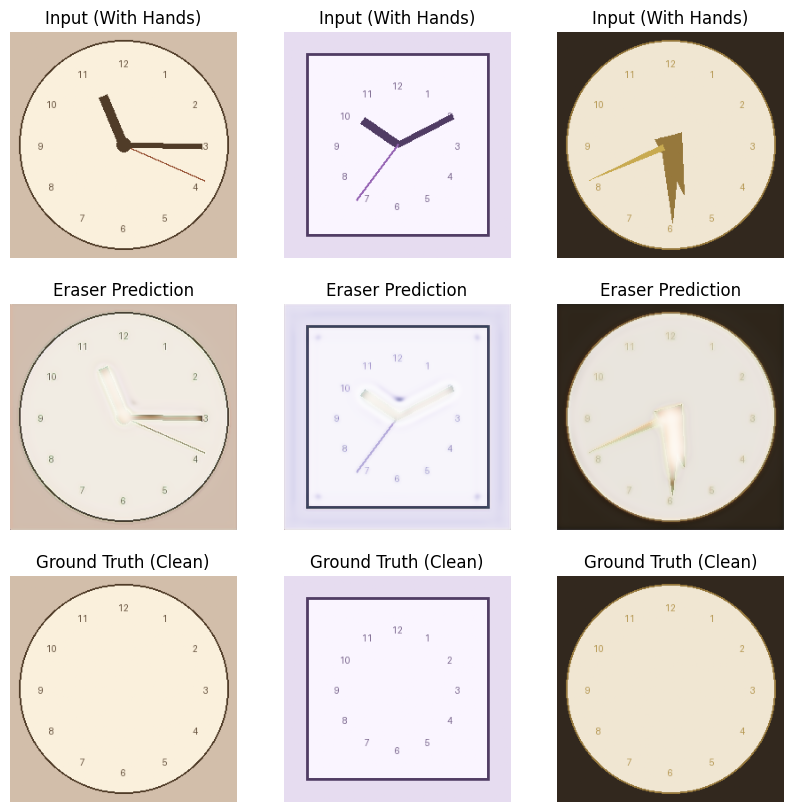

Epoch [6/50], Loss: 0.00232
  -> Saved best model!
Epoch [7/50], Loss: 0.00191
  -> Saved best model!
Epoch [8/50], Loss: 0.00173
  -> Saved best model!
Epoch [9/50], Loss: 0.00128
  -> Saved best model!
Epoch [10/50], Loss: 0.00120
  -> Saved best model!


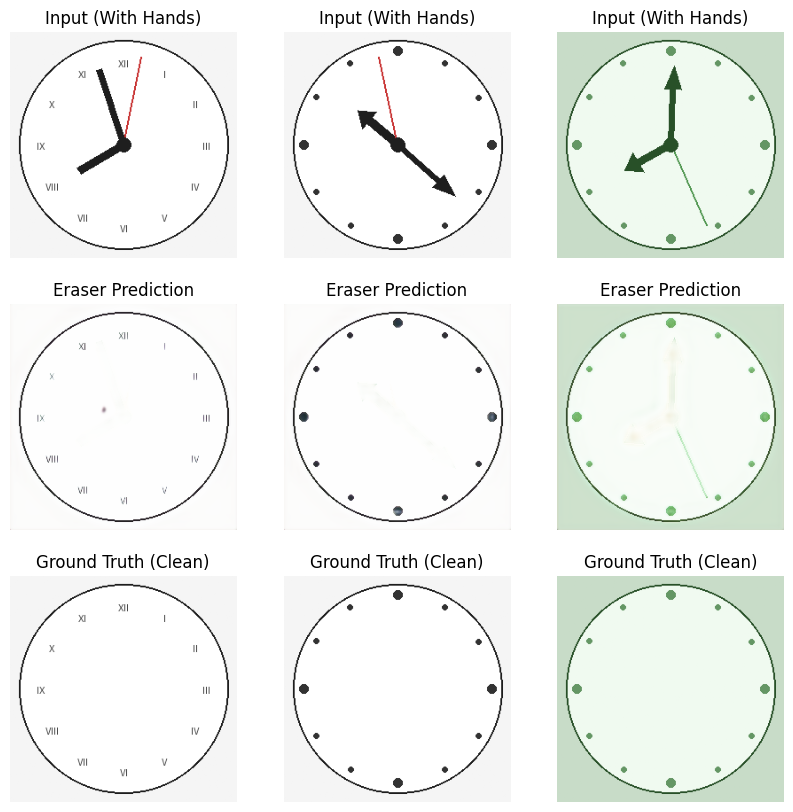

Epoch [11/50], Loss: 0.00173
Epoch [12/50], Loss: 0.00140
Epoch [13/50], Loss: 0.00197
Epoch [14/50], Loss: 0.00100
  -> Saved best model!
Epoch [15/50], Loss: 0.00077
  -> Saved best model!


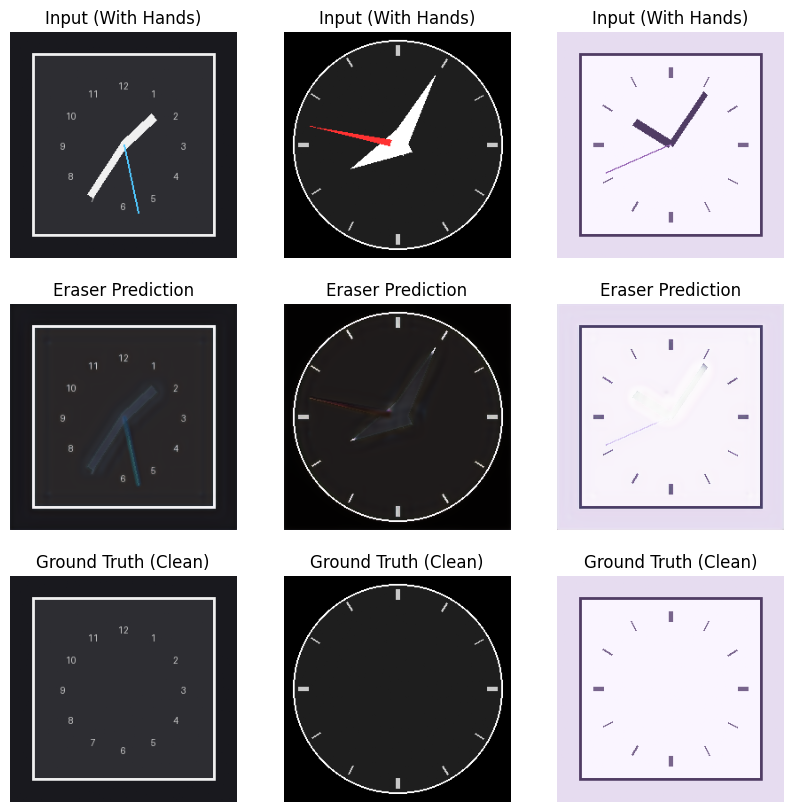

Epoch [16/50], Loss: 0.00077
Epoch [17/50], Loss: 0.00088
Epoch [18/50], Loss: 0.00074
  -> Saved best model!
Epoch [19/50], Loss: 0.00089
Epoch [20/50], Loss: 0.00115


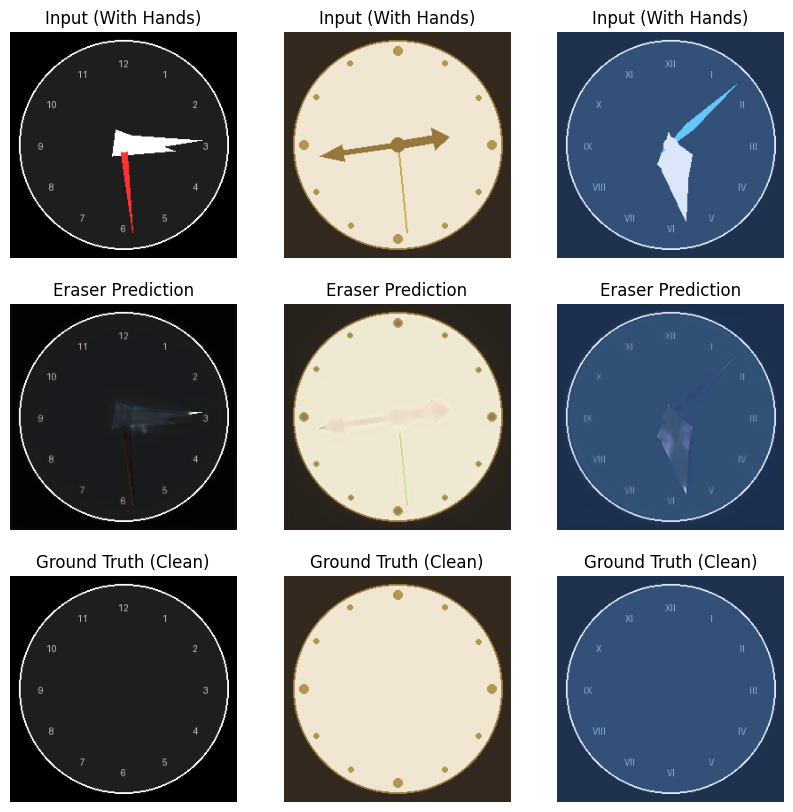

Epoch [21/50], Loss: 0.00063
  -> Saved best model!
Epoch [22/50], Loss: 0.00065
Epoch [23/50], Loss: 0.00054
  -> Saved best model!
Epoch [24/50], Loss: 0.00051
  -> Saved best model!
Epoch [25/50], Loss: 0.00046
  -> Saved best model!


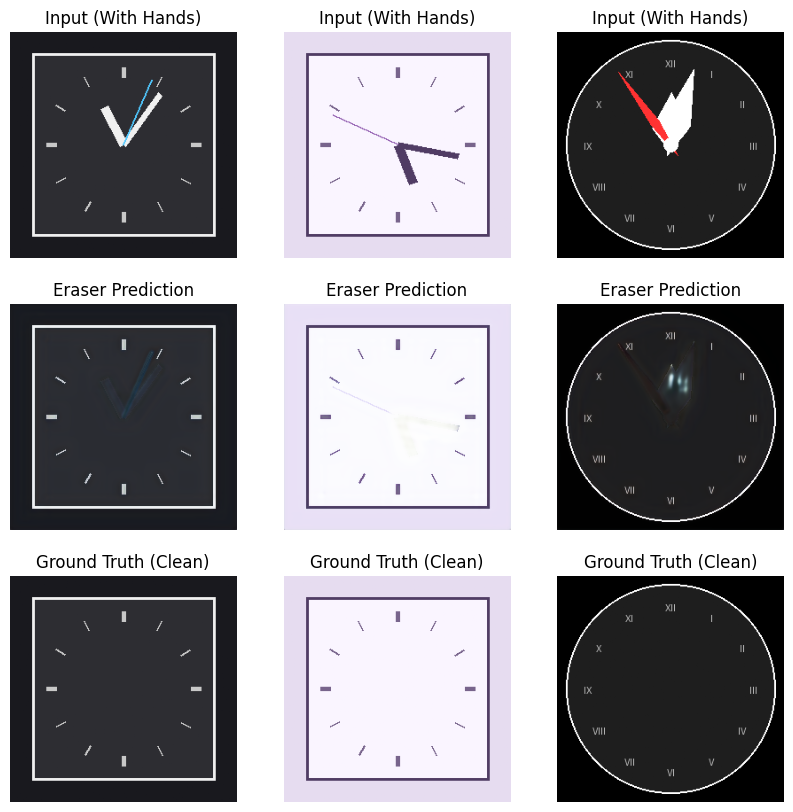

Epoch [26/50], Loss: 0.00081
Epoch [27/50], Loss: 0.00162
Epoch [28/50], Loss: 0.00185
Epoch [29/50], Loss: 0.00198
Epoch [30/50], Loss: 0.00085


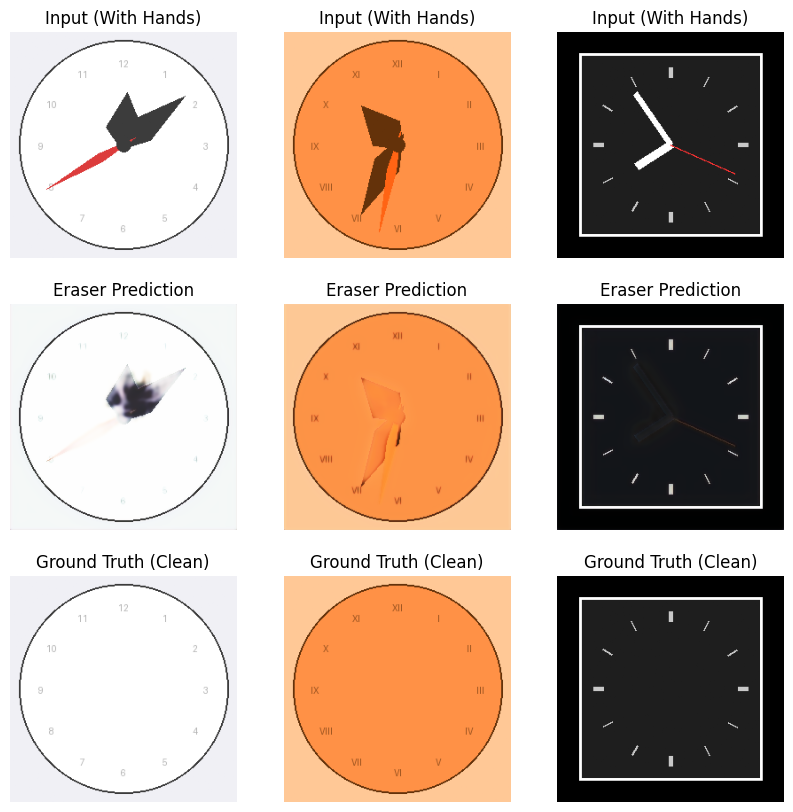

Epoch [31/50], Loss: 0.00081
Epoch [32/50], Loss: 0.00071
Epoch [33/50], Loss: 0.00043
  -> Saved best model!
Epoch [34/50], Loss: 0.00047
Epoch [35/50], Loss: 0.00050


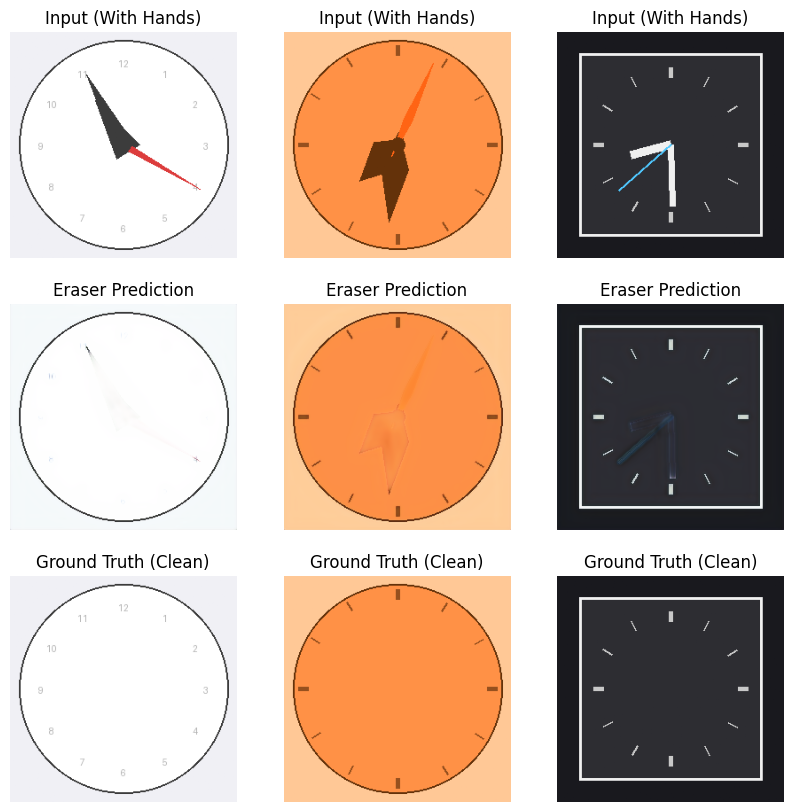

Epoch [36/50], Loss: 0.00044
Epoch [37/50], Loss: 0.00046
Epoch [38/50], Loss: 0.00044
Epoch [39/50], Loss: 0.00051
Epoch [40/50], Loss: 0.00038
  -> Saved best model!


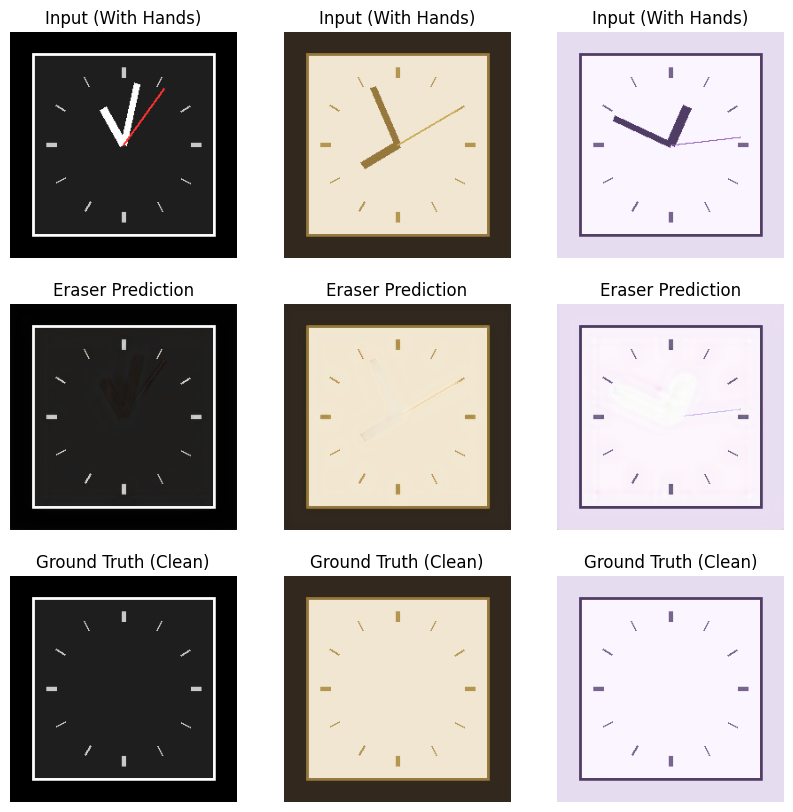

Epoch [41/50], Loss: 0.00031
  -> Saved best model!
Epoch [42/50], Loss: 0.00056
Epoch [43/50], Loss: 0.00089
Epoch [44/50], Loss: 0.00055
Epoch [45/50], Loss: 0.00044


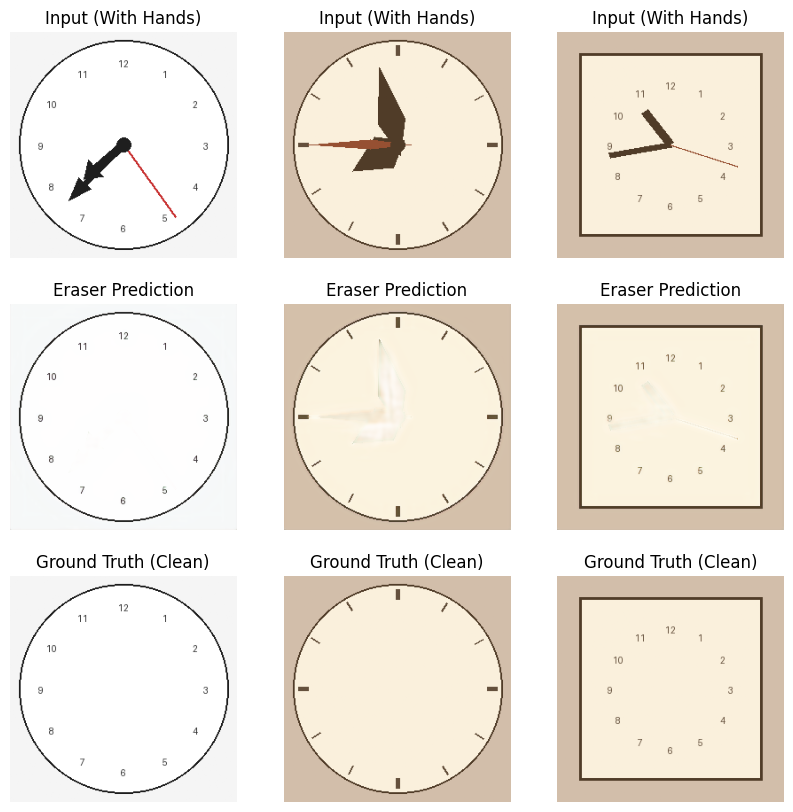

Epoch [46/50], Loss: 0.00037
Epoch [47/50], Loss: 0.00049
Epoch [48/50], Loss: 0.00043
Epoch [49/50], Loss: 0.00029
  -> Saved best model!
Epoch [50/50], Loss: 0.00116


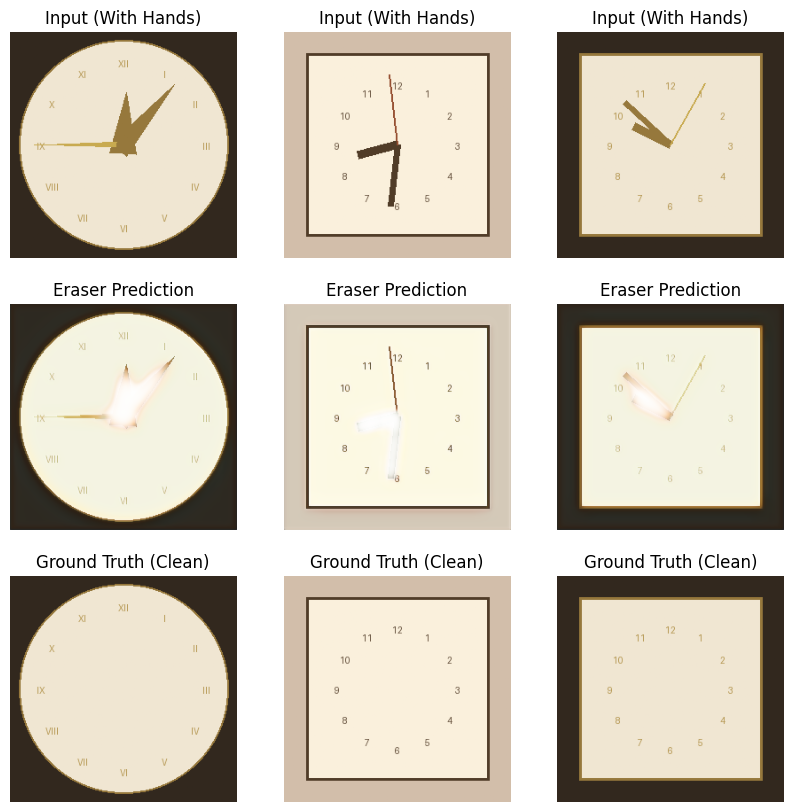

In [4]:

# ===================== Train Function =====================
def train_eraser(data_dir, num_epochs=20, batch_size=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")

    # Transforms to ensure all images are the same size and normalized
    transform = transforms.Compose([
        transforms.Resize((256, 256)), # Set a fixed size for all images
        transforms.ToTensor(),
    ])

    train_dataset = ClockDataset(data_dir, subset='train', transform=transform)
    test_dataset = ClockDataset(data_dir, subset='test', transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True) # Smaller batch for visualization

    model = ClockEraserUNet().to(device)
    criterion = nn.MSELoss() # L2 Loss for pixel-wise regression
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    os.makedirs('checkpoints', exist_ok=True)
    best_loss = float('inf')

    print("Starting Eraser Training...")
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for batch in train_loader:
            # Inputs: Watch images with hands (analog clock), Targets: Clean clock images (background only)
            inputs = batch['analog_img'].to(device)
            targets = batch['clean_img'].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.5f}")

        # Save best model
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "checkpoints/clock_eraser_best.pth")
            print("  -> Saved best model!")

        # Visualize results every 5 epochs
        if (epoch+1) % 5 == 0:
            visualize_results(model, test_loader, device)

def visualize_results(model, loader, device):
    model.eval()
    with torch.no_grad():
        batch = next(iter(loader))
        inputs = batch['analog_img'].to(device)
        targets = batch['clean_img'].to(device)
        outputs = model(inputs)
        
        # Show the first 3 results
        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        for i in range(3):
            if i >= len(inputs): break
            # Input
            axes[0, i].imshow(inputs[i].cpu().permute(1, 2, 0))
            axes[0, i].set_title("Input (With Hands)")
            axes[0, i].axis('off')
            # Output
            axes[1, i].imshow(outputs[i].cpu().permute(1, 2, 0))
            axes[1, i].set_title("Eraser Prediction")
            axes[1, i].axis('off')
            # Target
            axes[2, i].imshow(targets[i].cpu().permute(1, 2, 0))
            axes[2, i].set_title("Ground Truth (Clean)")
            axes[2, i].axis('off')
        plt.show()

if __name__ == "__main__":
    train_eraser(data_dir="../data", num_epochs=50)

# V2 

In [9]:
import os
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from dataset import ClockDataset

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

Using device: mps


In [10]:
# ===================== MODEL =====================

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ClockEraserV2(nn.Module):
    """
    4-level U-Net with skip connections.
    Input:  analog image with hands  (B, 3, H, W)
    Output: clean clock face         (B, 3, H, W)  values in [0, 1]
    """
    def __init__(self, base=64):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(3, base)
        self.enc2 = ConvBlock(base, base*2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.enc4 = ConvBlock(base*4, base*8)
        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.bottleneck = ConvBlock(base*8, base*8)

        # Decoder
        self.up4  = nn.ConvTranspose2d(base*8, base*8, 2, stride=2)
        self.dec4 = ConvBlock(base*8 + base*8, base*4)

        self.up3  = nn.ConvTranspose2d(base*4, base*4, 2, stride=2)
        self.dec3 = ConvBlock(base*4 + base*4, base*2)

        self.up2  = nn.ConvTranspose2d(base*2, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*2 + base*2, base)

        self.up1  = nn.ConvTranspose2d(base, base, 2, stride=2)
        self.dec1 = ConvBlock(base + base, base)

        self.final = nn.Sequential(
            nn.Conv2d(base, 3, 1),
            nn.Sigmoid()   # Output in [0, 1]
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self._up(self.up4, bn, e4), e4], dim=1))
        d3 = self.dec3(torch.cat([self._up(self.up3, d4, e3), e3], dim=1))
        d2 = self.dec2(torch.cat([self._up(self.up2, d3, e2), e2], dim=1))
        d1 = self.dec1(torch.cat([self._up(self.up1, d2, e1), e1], dim=1))

        return self.final(d1)

    @staticmethod
    def _up(upsample, x, skip):
        """Upsample and fix size mismatch from odd dimensions."""
        x = upsample(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return x

In [11]:
# ===================== LOSS =====================

class EraserLoss(nn.Module):
    """
    Weighted L1 loss: hand pixels get 5× more gradient signal.
    Also adds an edge-preservation term (Sobel) so tick marks
    and numbers on the clock face remain sharp after erasing.
    """
    def __init__(self, hand_weight=5.0, edge_weight=2.0):
        super().__init__()
        self.hw = hand_weight
        self.ew = edge_weight

        sx = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sy = torch.tensor([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        self.register_buffer('sx', sx)
        self.register_buffer('sy', sy)

    def _sobel(self, img):
        gray = 0.299*img[:,0:1] + 0.587*img[:,1:2] + 0.114*img[:,2:3]
        return torch.sqrt(
            F.conv2d(gray, self.sx, padding=1)**2 +
            F.conv2d(gray, self.sy, padding=1)**2 + 1e-6
        )

    def forward(self, pred, clean, analog):
        """
        pred   : model output             (B, 3, H, W)  in [0,1]
        clean  : target clean image       (B, 3, H, W)  in [0,1]
        analog : original (with hands)    (B, 3, H, W)  in [0,1]
        """
        # Identify hand pixels: where analog differs from clean
        diff = (analog - clean).abs().sum(dim=1, keepdim=True)
        hand_mask = (diff > 0.05).float()

        # Pixel loss — weighted
        pixel_loss = F.l1_loss(pred, clean, reduction='none')
        weight_map = 1.0 + (self.hw - 1.0) * hand_mask
        weighted_loss = (pixel_loss * weight_map).mean()

        # Edge loss — encourages sharp clock face details
        edge_loss = F.l1_loss(self._sobel(pred), self._sobel(clean))

        return weighted_loss + self.ew * edge_loss

In [12]:
# ===================== TRAINING =====================

def train(data_dir='./clock_dataset', num_epochs=40, batch_size=16, image_size=256, lr=2e-4):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])

    train_ds = ClockDataset(data_dir, subset='train', transform=transform)
    test_ds  = ClockDataset(data_dir, subset='test',  transform=transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=4,          shuffle=False, num_workers=0)

    model     = ClockEraserV2().to(device)
    criterion = EraserLoss(hand_weight=5.0, edge_weight=2.0).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    os.makedirs('checkpoints', exist_ok=True)
    best_val = float('inf')

    print(f"Training Eraser V2 at {image_size}px for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            analog = batch['analog_img'].to(device)
            clean  = batch['clean_img'].to(device)

            pred = model(analog)
            loss = criterion(pred, clean, analog)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in test_loader:
                analog = batch['analog_img'].to(device)
                clean  = batch['clean_img'].to(device)
                pred   = model(analog)
                val_loss += criterion(pred, clean, analog).item()

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(test_loader)
        print(f"Epoch [{epoch+1:>3}/{num_epochs}]  Train: {avg_train:.5f}  Val: {avg_val:.5f}")

        if avg_val < best_val:
            best_val = avg_val
            torch.save(model.state_dict(), 'checkpoints/eraser_v2_best.pth')
            print("  -> Saved!")

    print(f"\nTraining complete. Best val loss: {best_val:.5f}")

In [13]:
# ===================== EVALUATION =====================

def evaluate(data_dir='./clock_dataset', image_size=256, n=4):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])
    test_ds = ClockDataset(data_dir, subset='test', transform=transform)
    loader  = DataLoader(test_ds, batch_size=n, shuffle=True, num_workers=0)

    model = ClockEraserV2().to(device)
    model.load_state_dict(torch.load('checkpoints/eraser_v2_best.pth', map_location=device))
    model.eval()

    batch = next(iter(loader))
    analog = batch['analog_img'].to(device)
    clean  = batch['clean_img']

    with torch.no_grad():
        pred = model(analog).cpu()

    fig, axes = plt.subplots(3, n, figsize=(4*n, 12))
    for i in range(n):
        axes[0, i].imshow(analog[i].cpu().permute(1, 2, 0))
        axes[0, i].set_title("Input (with hands)")
        axes[1, i].imshow(pred[i].permute(1, 2, 0))
        axes[1, i].set_title("Erased (predicted)")
        axes[2, i].imshow(clean[i].permute(1, 2, 0))
        axes[2, i].set_title("Ground truth (clean)")
        for ax in axes[:, i]: ax.axis('off')
    plt.tight_layout()
    print("Saved eraser_eval.png")
    plt.show()

In [14]:
train(data_dir='./clock_dataset', num_epochs=80)

Training Eraser V2 at 256px for 80 epochs...
Epoch [  1/80]  Train: 0.48095  Val: 0.32690
  -> Saved!
Epoch [  2/80]  Train: 0.29800  Val: 0.24789
  -> Saved!
Epoch [  3/80]  Train: 0.21728  Val: 0.17424
  -> Saved!
Epoch [  4/80]  Train: 0.17268  Val: 0.11225
  -> Saved!
Epoch [  5/80]  Train: 0.12753  Val: 0.09229
  -> Saved!
Epoch [  6/80]  Train: 0.10029  Val: 0.07790
  -> Saved!
Epoch [  7/80]  Train: 0.11132  Val: 0.15514
Epoch [  8/80]  Train: 0.09426  Val: 0.08274
Epoch [  9/80]  Train: 0.08553  Val: 0.05586
  -> Saved!
Epoch [ 10/80]  Train: 0.07543  Val: 0.04736
  -> Saved!
Epoch [ 11/80]  Train: 0.06381  Val: 0.04848
Epoch [ 12/80]  Train: 0.07333  Val: 0.04677
  -> Saved!
Epoch [ 13/80]  Train: 0.07095  Val: 0.04376
  -> Saved!
Epoch [ 14/80]  Train: 0.05971  Val: 0.03663
  -> Saved!
Epoch [ 15/80]  Train: 0.06410  Val: 0.04060
Epoch [ 16/80]  Train: 0.05241  Val: 0.03738
Epoch [ 17/80]  Train: 0.05645  Val: 0.03407
  -> Saved!
Epoch [ 18/80]  Train: 0.04771  Val: 0.03002
 

Saved eraser_eval.png


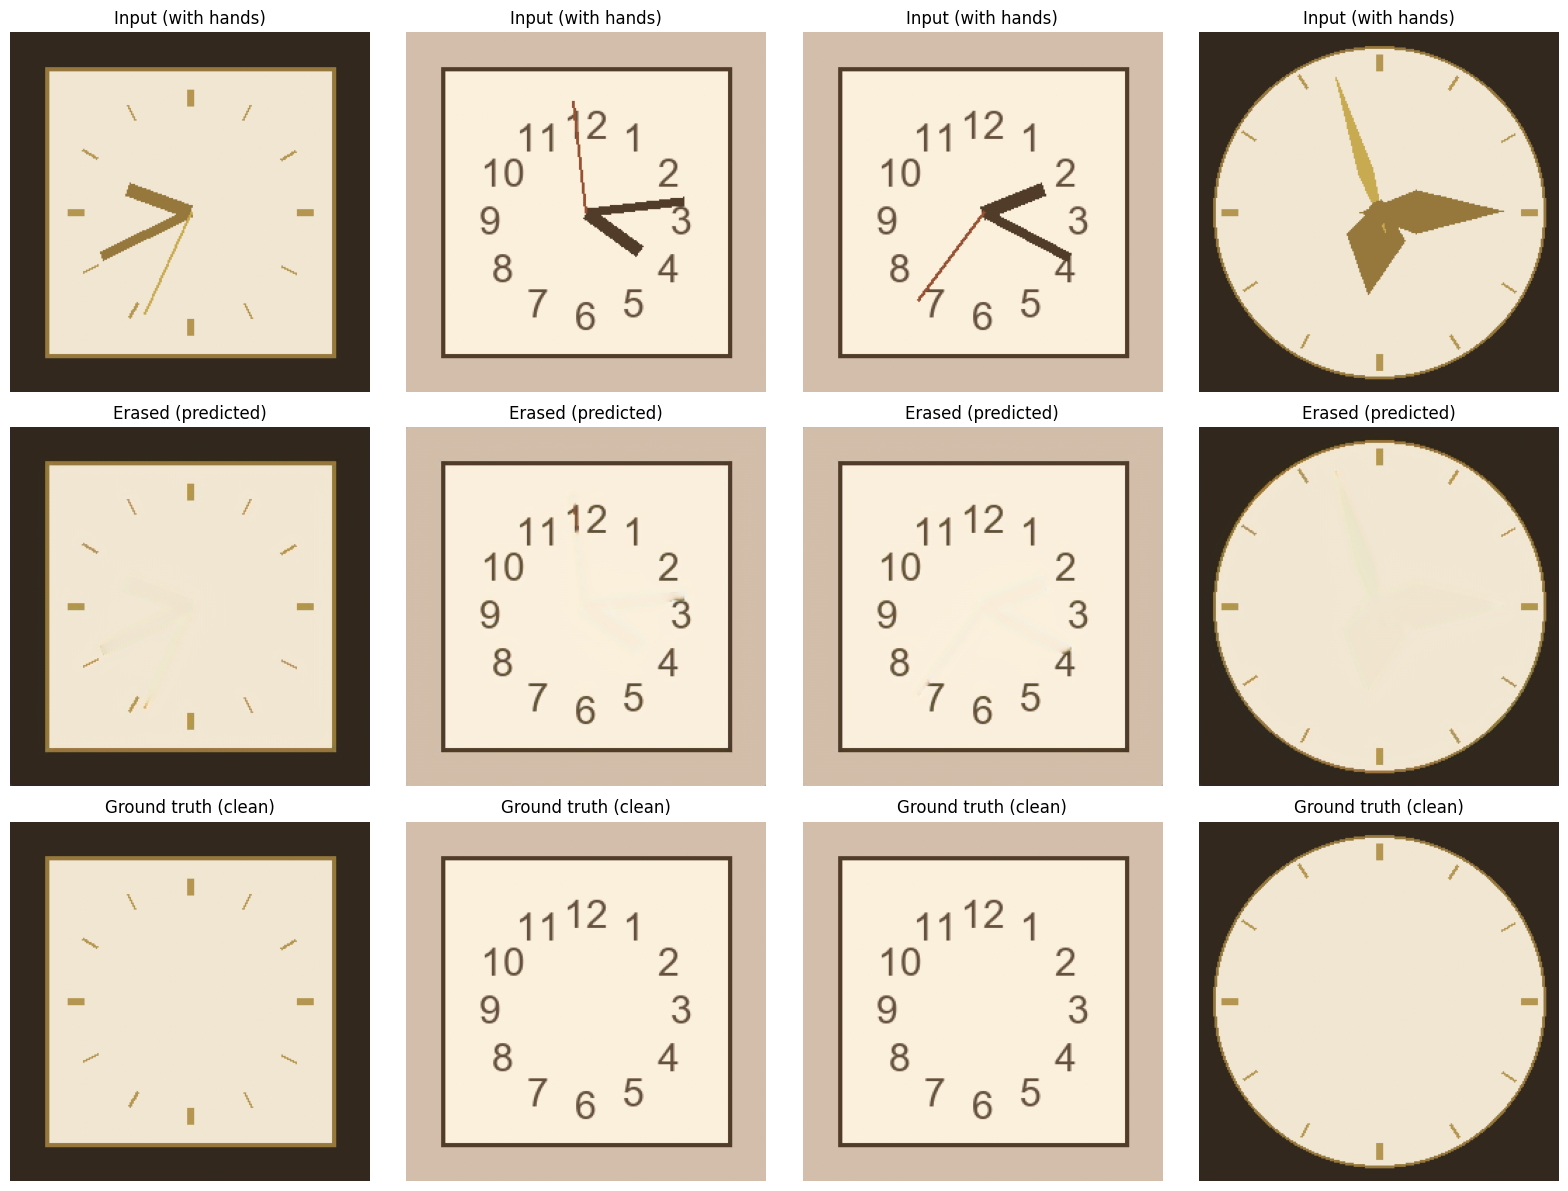

In [15]:
evaluate()